In [ ]:
# First imports: for setup
import os, sys

In [ ]:
# If in colab, clone the entire repo so that it can access files besides for this one
# And install requirements
IN_COLAB = "google.colab" in sys.modules
print(f"Running on Colab:{IN_COLAB}")

if IN_COLAB:
    if not os.path.exists("vis10n"):
        print("Cloning full repo")
        !git clone https://github.com/simchaorgel/vis10n.git
    !cd vis10n && git pull
    sys.path.append("vis10n")
    # Download requirements
    print("Downloading requirementss")
    !pip install -q -r vis10n/requirements.txt

In [ ]:
# Main imports
from torchvision import models, datasets, transforms
import torch as t
from dataclasses import dataclass
from torch.utils.data import Subset, DataLoader
import torch.nn.functional as F
from tqdm.notebook import tqdm
import wandb

In [15]:
# Local imports: this cell imports from the files, either run this
# or copy and run the file contents directly
from models.resnet_mnist_1 import Model
import optimizers
from optimizers.optimizers import AdamW

In [6]:
# Checks if we have access to a GPU
device = t.device("mps" if t.backends.mps.is_available() else "cuda" if t.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
# Wandb login
wandb.login()

In [9]:
# Load datasets (train and test sets)
# Transform
MNIST_TRANSFORM = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize(0.1307, 0.3081),
    ]
)

def get_mnist(trainset_size: int = 10_000, testset_size: int = 1_000) -> tuple[Subset, Subset]:
    """Returns a subset of MNIST training data."""
    # Get or download original datasets, which are downloaded to "data/" either locally or on colab
    mnist_trainset = datasets.MNIST("data/", train=True, download=True, transform=MNIST_TRANSFORM)
    mnist_testset = datasets.MNIST("data/", train=False, download=True, transform=MNIST_TRANSFORM)

    # Return a subset of the original datasets
    mnist_trainset = Subset(mnist_trainset, indices=range(trainset_size))
    mnist_testset = Subset(mnist_testset, indices=range(testset_size))
    
    return mnist_trainset, mnist_testset

In [8]:
# Training args
#####################################################
@dataclass
class ResNetTrainingArgs:
    trainset_size: int = 60000
    testset_size: int = 1000
    batch_size: int = 64
    epochs: int = 4
    learning_rate: float = 1e-3
    n_classes: int = 10

In [ ]:
# Train
#####################################################
def train(args: ResNetTrainingArgs) -> tuple[list[float], list[float], Model]:
    """
    Performs feature extraction on ResNet, returning the model & lists of loss and accuracy.
    """
    # Wandb init
    wandb.init(project="mnist-resnet", config=args)
    # Create ResNet instance
    model = Model().to(device)
    wandb.watch(model, log="all", log_freq=50)
    # Get data
    trainset, testset = get_mnist(args.trainset_size, args.testset_size)
    train_data = DataLoader(trainset, batch_size=args.batch_size, shuffle=True)
    test_data = DataLoader(testset, batch_size=args.batch_size, shuffle=False)
    # Define optimizer
    optimizer = AdamW(model.parameters(), lr=args.learning_rate)
    # Logging lists
    loss_list = []
    accuracy_list =[]
    examples_seen = 0

    # For every epoch:
    for epoch in range(args.epochs):
        epoch_accurate_predictions = 0 # For validating
        pbar = tqdm(train_data)

        # Train - loop for every batch in this epoch
        model.train()
        for imgs, labels in pbar:
            # Move data to device, perform forward pass
            imgs, labels = imgs.to(device), labels.to(device)
            logits = model(imgs)
            # Compute loss, perform backward pass
            loss = F.cross_entropy(logits, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            # Update logs & progress bar
            examples_seen += imgs.shape[0]
            loss_list.append(loss.item())
            pbar.set_postfix(epoch=f"{epoch + 1}/{args.epochs}", loss=f"{loss:.3f}")

        # Test to get accuracy
        model.eval()
        for imgs, labels in test_data:
            imgs, labels = imgs.to(device), labels.to(device)
            with t.inference_mode():
                logits = model(imgs)

            # Calculate accuracy
            # Get max logit, which is treated as the models guess
            predictions = t.argmax(logits, dim=1)
            # Create tensor with 1 if the prediction was correct, 0 if not, for every img
            accuracy_bools = predictions == labels
            # Number of accurate guesses
            epoch_accurate_predictions += accuracy_bools.sum().item()

        # Before completing the epoch
        # Add accuracy percentage to list
        epoch_accuracy = epoch_accurate_predictions / len(testset)
        accuracy_list.append(epoch_accuracy)
        wandb.log({"accuracy": epoch_accuracy}, step=examples_seen)

    wandb.finish()
    return loss_list, accuracy_list, model



args = ResNetTrainingArgs()
loss_list, accuracy_list, model = train(args)

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

  0%|          | 0/938 [00:00<?, ?it/s]

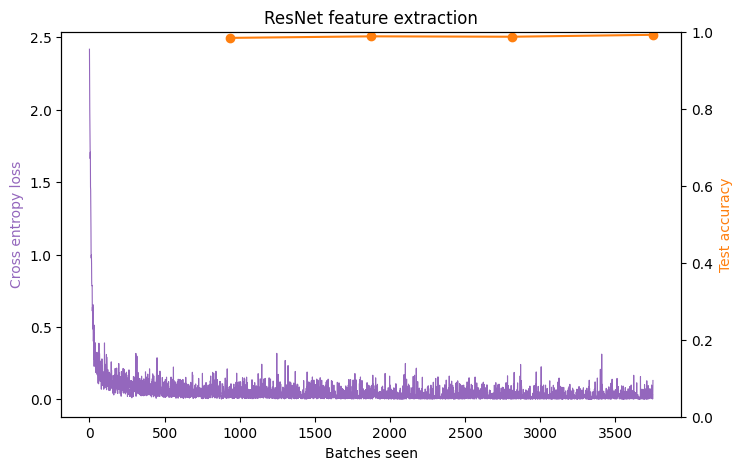

In [17]:
# Display training loss and accuracy
#####################################################
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(8, 5))

ax1.plot(loss_list, color="tab:purple", linewidth=0.8)
ax1.set_xlabel("Batches seen")
ax1.set_ylabel("Cross entropy loss", color="tab:purple")

# one accuracy point at the end of each epoch
batches_per_epoch = len(loss_list) / args.epochs
acc_x = [(i + 1) * batches_per_epoch for i in range(len(accuracy_list))]

ax2 = ax1.twinx()
ax2.plot(acc_x, accuracy_list, color="tab:orange", marker="o")
ax2.set_ylabel("Test accuracy", color="tab:orange")
ax2.set_ylim(0, 1)

plt.title("ResNet feature extraction")
plt.show()

In [18]:
# Run stats
#####################################################
# The accuracy here is what the import wizard asks for, in percent
final_accuracy = accuracy_list[-1]
best_accuracy = max(accuracy_list)
batches_per_epoch = len(loss_list) // args.epochs
final_epoch_loss = sum(loss_list[-batches_per_epoch:]) / batches_per_epoch

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"final accuracy   {final_accuracy:.2%}")
print(f"best accuracy    {best_accuracy:.2%}  (epoch {accuracy_list.index(best_accuracy) + 1})")
print(f"first loss       {loss_list[0]:.3f}")
print(f"final loss       {final_epoch_loss:.3f}  (mean over the last epoch)")
print()
print(f"epochs           {args.epochs}")
print(f"batch size       {args.batch_size}")
print(f"learning rate    {args.learning_rate}")
print(f"batches seen     {len(loss_list)}  ({batches_per_epoch} per epoch)")
print(f"train images     {batches_per_epoch * args.batch_size:,}")
print()
print(f"parameters       {total_params:,} total, {trainable_params:,} trainable")

final accuracy   99.20%
best accuracy    99.20%  (epoch 4)
first loss       2.418
final loss       0.026  (mean over the last epoch)

epochs           4
batch size       64
learning rate    0.001
batches seen     3752  (938 per epoch)
train images     60,032

parameters       707,722 total, 707,722 trainable


In [ ]:
# Save model !!! BROKEN IN VSCODE COLAB, WILL SWITCH TO WANDB STORING
############################################
t.save(model.state_dict(), "mnist_resnet.pt")
print("Weights saved locally")
if IN_COLAB:
    from google.colab import files; files.download("mnist_resnet.pt")
    print("Downloaded")

Weights saved locally


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded
